In [1]:
import os

IN_COLAB = False
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    print("Not running in Colab - skipping Drive mount. "
          "Set DRIVE_ROOT below to a local folder instead.")

DRIVE_ROOT = "/content/drive/MyDrive/skin_app" if IN_COLAB else "./skin_app"

TRAIN_DIR = os.path.join(DRIVE_ROOT, "train")
TEST_DIR = os.path.join(DRIVE_ROOT, "test")
CHECKPOINT_DIR = os.path.join(DRIVE_ROOT, "checkpoints")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
if not os.path.isdir(TRAIN_DIR):
    raise FileNotFoundError(
        f"Train folder not found at: {TRAIN_DIR}\n"
        f"Check that DRIVE_ROOT points at the parent of your 'train'/'test' folders. "
        f"Contents of DRIVE_ROOT: {os.listdir(DRIVE_ROOT) if os.path.isdir(DRIVE_ROOT) else 'DRIVE_ROOT itself does not exist'}"
    )
if not os.path.isdir(TEST_DIR):
    raise FileNotFoundError(f"Test folder not found at: {TEST_DIR}")

train_classes = sorted(
    d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))
)
test_classes = sorted(
    d for d in os.listdir(TEST_DIR) if os.path.isdir(os.path.join(TEST_DIR, d))
)
if train_classes != test_classes:
    raise ValueError(
        "Train and test folders contain different classes - fix this before training.\n"
        f"Train only: {sorted(set(train_classes) - set(test_classes))}\n"
        f"Test only:  {sorted(set(test_classes) - set(train_classes))}"
    )

print("Classes:", train_classes)

Mounted at /content/drive
Classes: ['Acne', 'Benign_tumors', 'Infestations_Bites', 'Moles', 'Sun_Sunlight_Damage', 'Unknown_Normal']


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import (
    ResNet50, EfficientNetV2B0, DenseNet121, MobileNetV3Large,
)
from tensorflow.keras.applications import resnet50, efficientnet_v2, densenet, mobilenet_v3
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.optimizers.schedules import CosineDecay
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.losses import CategoricalCrossentropy

IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

gpus = tf.config.list_physical_devices("GPU")
print(f"GPUs detected: {len(gpus)}" + ("" if gpus else " - training will be slow on CPU; "
      "in Colab go to Runtime > Change runtime type > GPU"))

# Mixed precision is only worth it on GPU; on CPU it can be slower.
if gpus:
    tf.keras.mixed_precision.set_global_policy("mixed_float16")

GPUs detected: 1


In [3]:
BACKBONE_REGISTRY = {
    "resnet50": dict(
        builder=ResNet50,
        preprocess=resnet50.preprocess_input,
        unfreeze_last_n=50,
    ),
    "efficientnetv2b0": dict(
        builder=EfficientNetV2B0,
        preprocess=efficientnet_v2.preprocess_input,
        unfreeze_last_n=40,
    ),
    "densenet121": dict(
        builder=DenseNet121,
        preprocess=densenet.preprocess_input,
        unfreeze_last_n=40,
    ),
    "mobilenetv3large": dict(
        builder=MobileNetV3Large,
        preprocess=mobilenet_v3.preprocess_input,
        unfreeze_last_n=30,
    ),
}

In [4]:
ACTIVE_BACKBONES = ["resnet50", "efficientnetv2b0"]

EPOCHS_STAGE1 = 20
EPOCHS_STAGE2 = 12

In [5]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.15),
], name="augmentation")


def make_datasets(preprocess_fn):
    train_raw = tf.keras.utils.image_dataset_from_directory(
        TRAIN_DIR, validation_split=0.2, subset="training", seed=SEED,
        image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, label_mode="categorical",
    )
    val_raw = tf.keras.utils.image_dataset_from_directory(
        TRAIN_DIR, validation_split=0.2, subset="validation", seed=SEED,
        image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, label_mode="categorical",
        shuffle=False,
    )
    test_raw = tf.keras.utils.image_dataset_from_directory(
        TEST_DIR, image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
        label_mode="categorical", shuffle=False,
    )

    def prep_train(x, y):
        x = data_augmentation(x, training=True)
        x = tf.cast(x, tf.float32)   # BUG FIX: force float32 before preprocessing so
        x = preprocess_fn(x)         # mixed_float16 never leaks into preprocess math
        return x, y

    def prep_eval(x, y):
        x = tf.cast(x, tf.float32)
        x = preprocess_fn(x)
        return x, y

    train_ds = train_raw.map(prep_train, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
    val_ds = val_raw.map(prep_eval, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
    test_ds = test_raw.map(prep_eval, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
    return train_raw, val_raw, test_raw, train_ds, val_ds, test_ds

Found 6313 files belonging to 6 classes.
Using 5051 files for training.
Found 6313 files belonging to 6 classes.
Using 1262 files for validation.
Found 4563 files belonging to 6 classes.
Acne                   1976
Benign_tumors           832
Infestations_Bites      401
Moles                   287
Sun_Sunlight_Damage     251
Unknown_Normal         1304
Name: count, dtype: int64


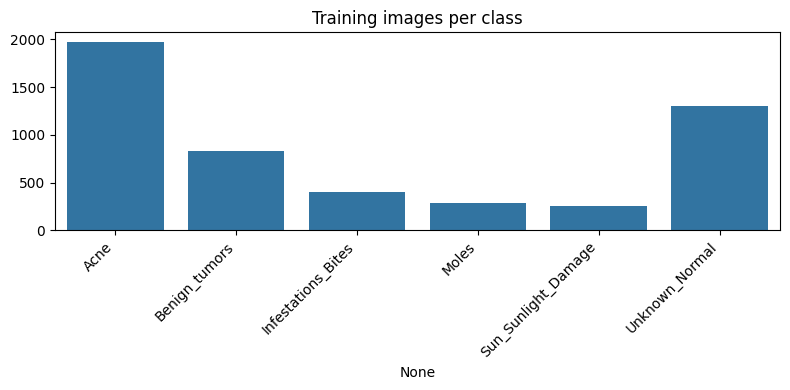

In [6]:
_label_probe, _, _, _, _, _ = make_datasets(lambda x: x)  # cheap: just lists files
CLASS_NAMES = _label_probe.class_names
NUM_CLASSES = len(CLASS_NAMES)

train_labels_idx = np.array([
    CLASS_NAMES.index(os.path.basename(os.path.dirname(p)))
    for p in _label_probe.file_paths
])

counts = pd.Series(train_labels_idx).value_counts().sort_index()
counts.index = CLASS_NAMES
print(counts)

plt.figure(figsize=(8, 4))
sns.barplot(x=counts.index, y=counts.values)
plt.title("Training images per class")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [7]:
class_weights_arr = compute_class_weight(
    class_weight="balanced", classes=np.arange(NUM_CLASSES), y=train_labels_idx
)
class_weights = dict(enumerate(class_weights_arr))
print("Class weights:", class_weights)

Class weights: {0: np.float64(0.4260290148448043), 1: np.float64(1.0118189102564104), 2: np.float64(2.099334995843724), 3: np.float64(2.9332171893147505), 4: np.float64(3.353917662682603), 5: np.float64(0.6455777096114519)}


In [8]:
def focal_loss(gamma=2.0, label_smoothing=0.05):
    cce = CategoricalCrossentropy(label_smoothing=label_smoothing, reduction="none")

    def loss_fn(y_true, y_pred):
        ce = cce(y_true, y_pred)
        p_t = tf.reduce_sum(y_true * y_pred, axis=-1)
        modulating_factor = tf.pow(1.0 - p_t, gamma)
        return tf.reduce_mean(modulating_factor * ce)

    return loss_fn

In [9]:
def build_model(backbone_key):
    cfg = BACKBONE_REGISTRY[backbone_key]
    base_model = cfg["builder"](
        input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights="imagenet"
    )
    base_model.trainable = False

    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)

    model = Model(inputs, outputs, name=backbone_key)
    return model, base_model

In [10]:
def load_pretrained_backbone(backbone_key, max_retries=3):
    """ImageNet weight downloads occasionally fail on Colab due to a flaky
    connection - retry a couple of times with a clear error instead of a
    cryptic 403/urllib traceback on the first hiccup."""
    last_err = None
    for attempt in range(1, max_retries + 1):
        try:
            return build_model(backbone_key)
        except Exception as e:  # noqa: BLE001
            last_err = e
            print(f"[{backbone_key}] weight download attempt {attempt} failed: {e}")
    raise RuntimeError(
        f"Could not download ImageNet weights for {backbone_key} after "
        f"{max_retries} attempts. Check your internet connection / Colab "
        f"network status and re-run this cell."
    ) from last_err

In [11]:
def train_one_backbone(backbone_key):
    print(f"\n{'=' * 60}\nTraining backbone: {backbone_key}\n{'=' * 60}")
    cfg = BACKBONE_REGISTRY[backbone_key]
    train_raw, val_raw, test_raw, train_ds, val_ds, test_ds = make_datasets(cfg["preprocess"])
    steps_per_epoch = max(int(train_raw.cardinality().numpy()), 1)

    model, base_model = load_pretrained_backbone(backbone_key)

    ckpt_path = os.path.join(CHECKPOINT_DIR, f"best_{backbone_key}.keras")
    callbacks = [
        EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
        ModelCheckpoint(ckpt_path, monitor="val_loss", save_best_only=True),
    ]

    # --- Stage 1: train the head, base frozen ---
    lr_schedule = CosineDecay(initial_learning_rate=1e-3, decay_steps=steps_per_epoch * EPOCHS_STAGE1)
    model.compile(
        optimizer=AdamW(learning_rate=lr_schedule, weight_decay=1e-4),
        loss=CategoricalCrossentropy(label_smoothing=0.05),
        metrics=["accuracy"],
    )
    history1 = model.fit(
        train_ds, validation_data=val_ds, epochs=EPOCHS_STAGE1,
        class_weight=class_weights, callbacks=callbacks,
    )

    # --- Stage 2: unfreeze the top of the backbone, fine-tune at a low LR ---
    base_model.trainable = True
    for layer in base_model.layers[:-cfg["unfreeze_last_n"]]:
        layer.trainable = False

    fine_tune_schedule = CosineDecay(initial_learning_rate=1e-5, decay_steps=steps_per_epoch * EPOCHS_STAGE2)
    model.compile(
        optimizer=AdamW(learning_rate=fine_tune_schedule, weight_decay=1e-5),
        loss=CategoricalCrossentropy(label_smoothing=0.05),
        metrics=["accuracy"],
    )
    history2 = model.fit(
        train_ds, validation_data=val_ds, epochs=EPOCHS_STAGE2,
        class_weight=class_weights, callbacks=callbacks,
    )

    final_path = os.path.join(CHECKPOINT_DIR, f"final_{backbone_key}.keras")
    model.save(final_path)

    return dict(
        model=model, history1=history1.history, history2=history2.history,
        test_raw=test_raw, test_ds=test_ds, final_path=final_path,
    )


trained = {key: train_one_backbone(key) for key in ACTIVE_BACKBONES}


Training backbone: resnet50
Found 6313 files belonging to 6 classes.
Using 5051 files for training.
Found 6313 files belonging to 6 classes.
Using 1262 files for validation.
Found 4563 files belonging to 6 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Epoch 1/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 2937s 18s/step - accuracy: 0.6510 - loss: 1.7122 - val_accuracy: 0.8803 - val_loss: 0.6975
Epoch 2/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 157s 981ms/step - accuracy: 0.7345 - loss: 1.2147 - val_accuracy: 0.9255 - val_loss: 0.6200
Epoch 3/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 201s 980ms/step - accuracy: 0.7597 - loss: 1.0839 - val_accuracy: 0.9604 - val_loss: 0.5575
Epoch 4/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 160s 1s/step - accuracy: 0.7897 - loss: 0.9755 - val_accuracy: 0.9643 - val_loss: 0.5538
Epoch 5/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 159s 1s/step - accuracy: 0.8066 - loss: 0.9023 - val_accuracy: 0.9580 - val_loss: 0.5342
Epoch 6/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.8177 - loss: 

In [12]:
def plot_history(history, title=""):
    acc, val_acc = history["accuracy"], history["val_accuracy"]
    loss, val_loss = history["loss"], history["val_loss"]
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label="Train Accuracy")
    plt.plot(epochs_range, val_acc, label="Validation Accuracy")
    plt.legend(loc="lower right")
    plt.title(f"{title} Accuracy")

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label="Train Loss")
    plt.plot(epochs_range, val_loss, label="Validation Loss")
    plt.legend(loc="upper right")
    plt.title(f"{title} Loss")
    plt.show()

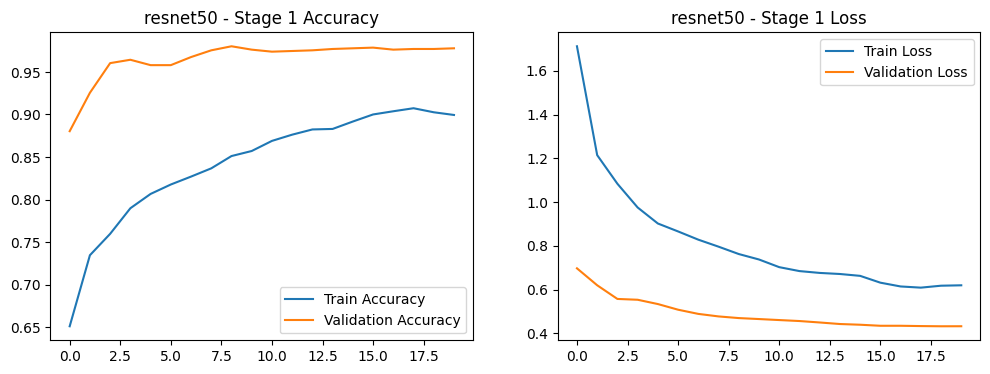

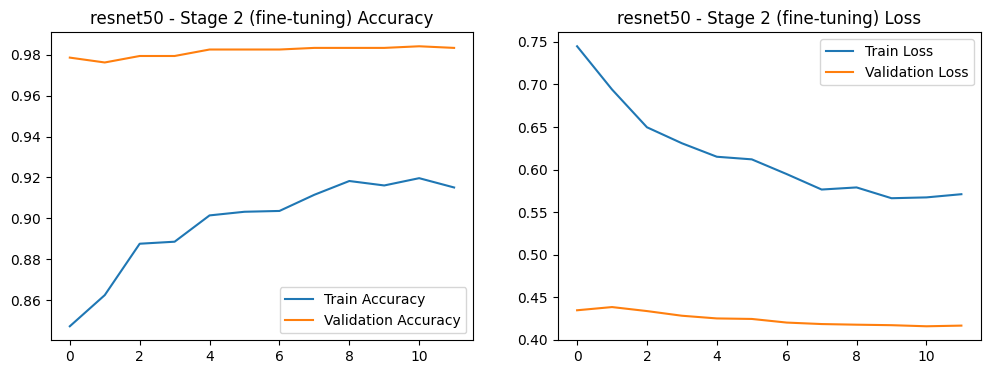

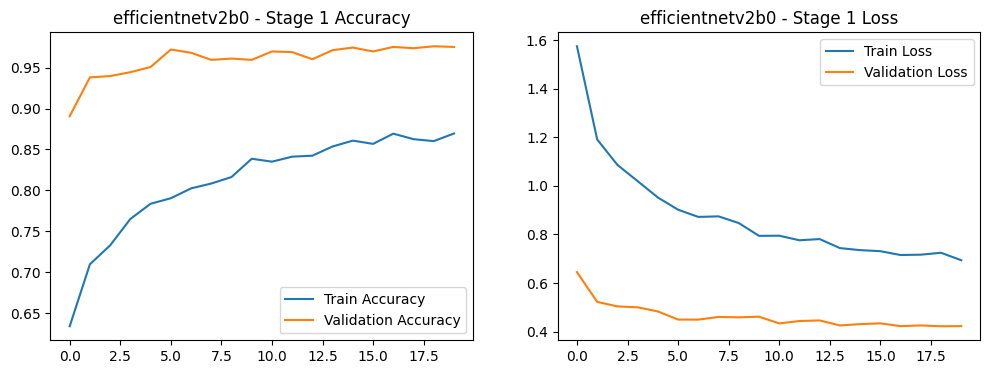

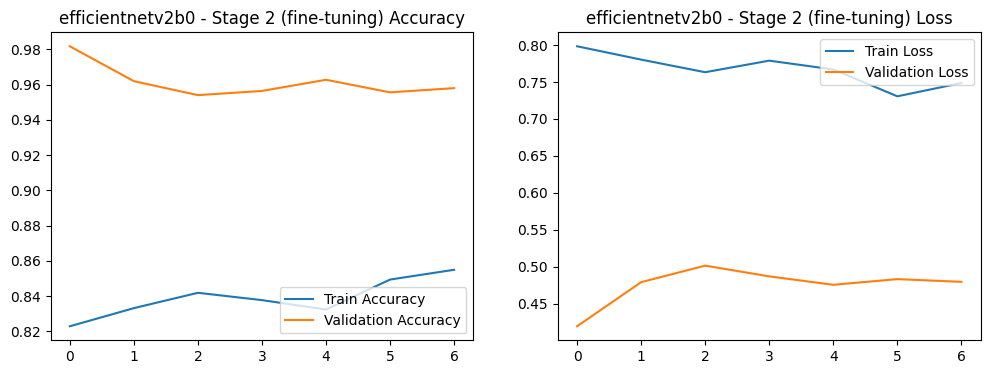

In [13]:
for key, res in trained.items():
    plot_history(res["history1"], f"{key} - Stage 1")
    plot_history(res["history2"], f"{key} - Stage 2 (fine-tuning)")

           model  test_accuracy
        resnet50       0.901162
efficientnetv2b0       0.814377
  ENSEMBLE (avg)       0.900066


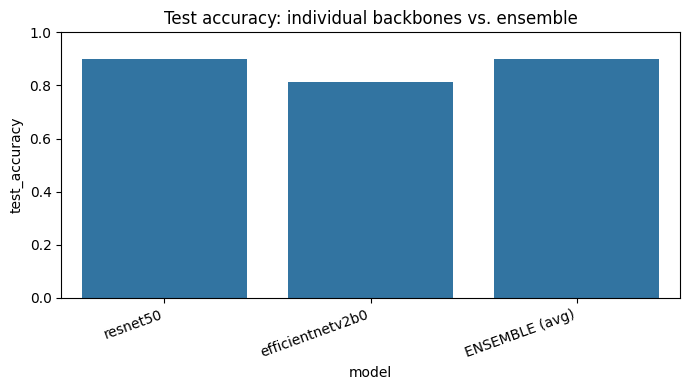


Ensemble classification report:
                     precision    recall  f1-score   support

               Acne       1.00      0.85      0.92      1785
      Benign_tumors       0.77      0.89      0.83       793
 Infestations_Bites       0.84      0.83      0.83       233
              Moles       0.64      0.93      0.76       211
Sun_Sunlight_Damage       0.76      0.87      0.81       310
     Unknown_Normal       1.00      1.00      1.00      1231

           accuracy                           0.90      4563
          macro avg       0.83      0.89      0.86      4563
       weighted avg       0.92      0.90      0.90      4563



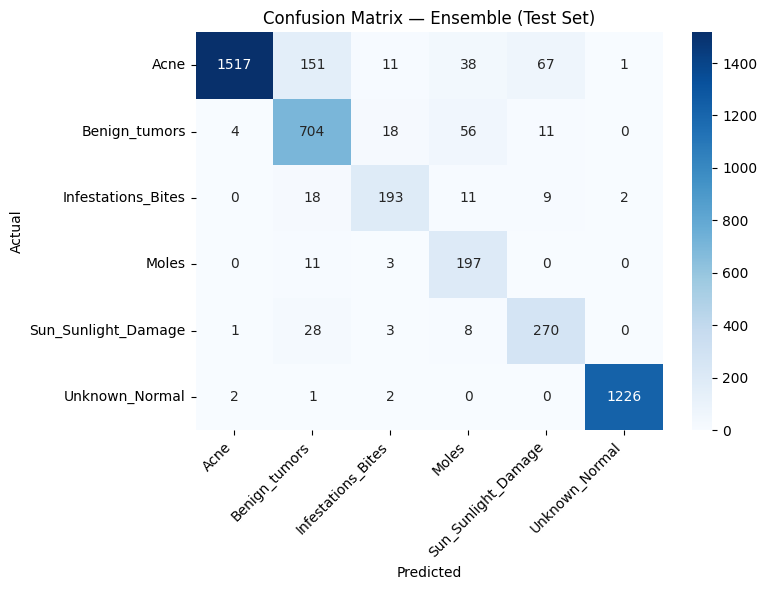

In [14]:
per_model_probs = {}
y_true = None
for key, res in trained.items():
    probs = res["model"].predict(res["test_ds"], verbose=0)
    per_model_probs[key] = probs
    if y_true is None:
        y_true = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in res["test_raw"]], axis=0)

summary_rows = []
for key, probs in per_model_probs.items():
    acc = (np.argmax(probs, axis=1) == y_true).mean()
    summary_rows.append({"model": key, "test_accuracy": acc})

ensemble_probs = np.mean(np.stack(list(per_model_probs.values()), axis=0), axis=0)
ensemble_pred = np.argmax(ensemble_probs, axis=1)
ensemble_acc = (ensemble_pred == y_true).mean()
summary_rows.append({"model": "ENSEMBLE (avg)", "test_accuracy": ensemble_acc})

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

plt.figure(figsize=(7, 4))
sns.barplot(data=summary_df, x="model", y="test_accuracy")
plt.ylim(0, 1)
plt.title("Test accuracy: individual backbones vs. ensemble")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

print("\nEnsemble classification report:")
print(classification_report(y_true, ensemble_pred, target_names=CLASS_NAMES, zero_division=0))

cm = confusion_matrix(y_true, ensemble_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Ensemble (Test Set)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [15]:
def load_and_preprocess(image_path):
    img = tf.keras.utils.load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
    img = tf.keras.utils.img_to_array(img)
    return img


def predict_skin_disease_tta(image_path, n_aug=5, threshold=60):
    base_img = load_and_preprocess(image_path)
    views = [base_img]
    for _ in range(n_aug):
        aug_img = data_augmentation(tf.expand_dims(base_img, 0), training=True)[0]
        views.append(aug_img.numpy())
    views = np.stack(views).astype("float32")

    all_model_avgs = []
    for key, res in trained.items():
        preprocess_fn = BACKBONE_REGISTRY[key]["preprocess"]
        batch = preprocess_fn(tf.constant(views))
        preds = res["model"].predict(batch, verbose=0)
        all_model_avgs.append(preds.mean(axis=0))

    avg_pred = np.mean(all_model_avgs, axis=0)
    class_index = np.argmax(avg_pred)
    confidence = avg_pred[class_index] * 100
    label = CLASS_NAMES[class_index]

    if confidence < threshold:
        return "No Clear Disease", confidence
    return label, confidence

In [1]:
import os, numpy as np, tensorflow as tf
from tensorflow.keras import layers

IN_COLAB = False
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    pass

DRIVE_ROOT     = "/content/drive/MyDrive/skin_app" if IN_COLAB else "./skin_app"
TRAIN_DIR      = os.path.join(DRIVE_ROOT, "train")
CHECKPOINT_DIR = os.path.join(DRIVE_ROOT, "checkpoints")
IMG_SIZE       = 224
SEED           = 42

CLASS_NAMES = sorted(
    d for d in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, d))
)
NUM_CLASSES = len(CLASS_NAMES)
print(f"Classes ({NUM_CLASSES}):", CLASS_NAMES)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.15),
], name="augmentation")

from tensorflow.keras.applications import resnet50, efficientnet_v2

BACKBONE_REGISTRY = {
    "resnet50":        {"preprocess": resnet50.preprocess_input},
    "efficientnetv2b0": {"preprocess": efficientnet_v2.preprocess_input},
}

trained = {}
for backbone_key in BACKBONE_REGISTRY:
    # Try final model first, fall back to best checkpoint
    for fname in [f"final_{backbone_key}.keras", f"best_{backbone_key}.keras"]:
        ckpt_path = os.path.join(CHECKPOINT_DIR, fname)
        if os.path.exists(ckpt_path):
            print(f"Loading {backbone_key} from {fname} ...")
            trained[backbone_key] = {
                "model": tf.keras.models.load_model(ckpt_path, compile=False)
            }
            print(f"  ✓ {backbone_key} loaded")
            break
    else:
        print(f"  ✗ No checkpoint found for {backbone_key} in {CHECKPOINT_DIR}")

print(f"\nLoaded {len(trained)} model(s): {list(trained.keys())}")

Mounted at /content/drive
Classes (6): ['Acne', 'Benign_tumors', 'Infestations_Bites', 'Moles', 'Sun_Sunlight_Damage', 'Unknown_Normal']
Loading resnet50 from final_resnet50.keras ...
  ✓ resnet50 loaded
Loading efficientnetv2b0 from final_efficientnetv2b0.keras ...
  ✓ efficientnetv2b0 loaded

Loaded 2 model(s): ['resnet50', 'efficientnetv2b0']


In [2]:
def predict_topk(image_path, top_k=5, n_aug=5, threshold=30.0):
    """
    Returns
    -------
    list of (label, confidence_pct) sorted by confidence descending,
    length = top_k.
    If the top-1 confidence < threshold, the first entry label is
    'No Clear Disease'.
    """
    img = tf.keras.utils.load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
    base = tf.keras.utils.img_to_array(img).astype("float32")

    views = [base]
    for _ in range(n_aug):
        aug = data_augmentation(tf.expand_dims(base, 0), training=True)[0].numpy()
        views.append(aug)
    views = np.stack(views)                                 # (n_aug+1, H, W, 3)

    model_avgs = []
    for key, res in trained.items():
        prep = BACKBONE_REGISTRY[key]["preprocess"]
        batch = prep(tf.constant(views)).numpy()
        preds = res["model"].predict(batch, verbose=0)      # (n_aug+1, NUM_CLASSES)
        model_avgs.append(preds.mean(axis=0))               # (NUM_CLASSES,)

    avg = np.mean(model_avgs, axis=0)                       # (NUM_CLASSES,)

    top_idx = np.argsort(avg)[::-1][:top_k]
    results = [(CLASS_NAMES[i], float(avg[i]) * 100) for i in top_idx]

    if results[0][1] < threshold:
        results[0] = ("No Clear Disease", results[0][1])

    return results

print("predict_topk() ready.")

predict_topk() ready.


In [3]:
# ── Interactive Frontend ──────────────────────────────────────────────────────
import io, base64, IPython.display as ipd
import ipywidgets as widgets
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

# ── Colour palette ─────────────────────────────────────────────────────────
PALETTE = [
    "#2A6EBB", "#4A9FD4", "#7DC3E8", "#A8D8EA", "#C9EBF5"
]
BG      = "#F7FAFB"
CARD_BG = "#FFFFFF"
TEXT    = "#1A2332"
ACCENT  = "#2A6EBB"

# ── Widget layout ─────────────────────────────────────────────────────────
style = {'description_width': '0px'}

title_html = widgets.HTML(
    value=(
        "<div style='background:#2A6EBB;padding:18px 24px;border-radius:10px;"
        "margin-bottom:12px;'>"
        "<h2 style='color:white;margin:0;font-family:sans-serif;letter-spacing:1px;'>"
        "🔬 Skin Disease Classifier</h2>"
        "<p style='color:#C9EBF5;margin:4px 0 0;font-family:sans-serif;font-size:13px;'>"
        f"Ensemble of {len(trained)} backbone(s) · Top-5 predictions · TTA enabled</p>"
        "</div>"
    )
)

upload_btn = widgets.FileUpload(
    accept='image/*',
    multiple=True,
    description='Upload Images',
    button_style='primary',
    layout=widgets.Layout(width='200px'),
)

run_btn = widgets.Button(
    description='Run Predictions',
    button_style='success',
    icon='play',
    layout=widgets.Layout(width='180px', height='36px'),
)

status = widgets.HTML(value="<i style='color:#888;font-family:sans-serif;'>Upload image(s) then click Run Predictions.</i>")
output = widgets.Output()

top_k_slider = widgets.IntSlider(
    value=5, min=1, max=min(10, NUM_CLASSES),
    description='Top-K', style=style,
    layout=widgets.Layout(width='260px'),
)
tta_slider = widgets.IntSlider(
    value=5, min=1, max=15,
    description='TTA views', style=style,
    layout=widgets.Layout(width='260px'),
)
threshold_slider = widgets.FloatSlider(
    value=30.0, min=0, max=90, step=5,
    description='Conf. threshold %', style=style,
    readout_format='.0f',
    layout=widgets.Layout(width='320px'),
)

controls = widgets.HBox(
    [top_k_slider, tta_slider, threshold_slider],
    layout=widgets.Layout(gap='20px', flex_wrap='wrap', margin='8px 0')
)
btn_row = widgets.HBox(
    [upload_btn, run_btn],
    layout=widgets.Layout(gap='12px', align_items='center')
)

# ── Plotting helper ────────────────────────────────────────────────────────
def make_result_figure(pil_img, predictions, filename):
    """
    Creates a side-by-side figure: skin image (left) + horizontal bar
    chart of top-k predictions (right).
    """
    top_k = len(predictions)
    fig = plt.figure(figsize=(12, max(3.5, top_k * 0.75 + 1.5)),
                     facecolor=BG)
    gs = GridSpec(1, 2, figure=fig, width_ratios=[1, 1.6], wspace=0.08)

    # ── Left: image ────────────────────────────────────────────────────
    ax_img = fig.add_subplot(gs[0])
    ax_img.imshow(pil_img)
    ax_img.set_title(filename, fontsize=10, color=TEXT,
                     fontfamily='monospace', pad=6)
    ax_img.axis('off')
    ax_img.set_facecolor(BG)

    # ── Right: bar chart ───────────────────────────────────────────────
    ax_bar = fig.add_subplot(gs[1])
    ax_bar.set_facecolor(CARD_BG)
    fig.patch.set_facecolor(BG)

    labels  = [p[0] for p in predictions]
    confs   = [p[1] for p in predictions]
    colors  = [PALETTE[i % len(PALETTE)] for i in range(top_k)]

    # Draw bars (reversed so rank-1 is at the top)
    y_pos = list(range(top_k - 1, -1, -1))
    bars = ax_bar.barh(y_pos, confs[::-1], color=colors[::-1],
                       edgecolor='none', height=0.55)

    # Confidence labels inside / beside bars
    for bar, conf in zip(bars, confs[::-1]):
        x_text = min(conf + 1, 95)
        ha = 'left' if conf < 85 else 'right'
        ax_bar.text(x_text, bar.get_y() + bar.get_height() / 2,
                    f"{conf:.1f}%",
                    va='center', ha=ha, fontsize=10, color=TEXT, fontweight='bold')

    ax_bar.set_yticks(y_pos)
    ax_bar.set_yticklabels(
        [f"{'★ ' if i == 0 else f'#{i+1}  '}{l}" for i, l in enumerate(labels[::-1])],
        fontsize=10, color=TEXT
    )
    ax_bar.set_xlabel('Confidence (%)', color=TEXT, fontsize=10)
    ax_bar.set_xlim(0, 105)
    ax_bar.tick_params(axis='x', colors=TEXT)
    ax_bar.tick_params(axis='y', length=0)
    ax_bar.spines[['top', 'right', 'left']].set_visible(False)
    ax_bar.spines['bottom'].set_color('#CCCCCC')
    ax_bar.set_title('Top Predictions', color=TEXT, fontsize=12,
                     fontweight='bold', pad=10)

    # Highlight top-1
    ax_bar.get_yticklabels()[-1].set_fontweight('bold')
    ax_bar.get_yticklabels()[-1].set_color(ACCENT)

    plt.tight_layout(pad=1.5)
    return fig


# ── Button callback ────────────────────────────────────────────────────────
def on_run(btn):
    output.clear_output(wait=True)

    if not upload_btn.value:
        status.value = "<span style='color:#CC0000;font-family:sans-serif;'>⚠ No images uploaded yet.</span>"
        return

    files = upload_btn.value          # dict: {filename: {content: bytes, ...}}
    n     = len(files)
    status.value = (
        f"<span style='color:#2A6EBB;font-family:sans-serif;'>"
        f"⏳ Running predictions on {n} image(s)…</span>"
    )

    with output:
        for fname, meta in files.items():
            # Write to a temp file so TF can load it
            tmp_path = f"/tmp/skin_upload_{fname}"
            raw = meta['content'] if isinstance(meta, dict) else bytes(meta)
            with open(tmp_path, 'wb') as f:
                f.write(raw)

            try:
                pil_img     = tf.keras.utils.load_img(tmp_path)
                predictions = predict_topk(
                    tmp_path,
                    top_k=top_k_slider.value,
                    n_aug=tta_slider.value,
                    threshold=threshold_slider.value,
                )
                fig = make_result_figure(pil_img, predictions, fname)
                plt.show()
                plt.close(fig)
            except Exception as e:
                print(f"❌  Error on {fname}: {e}")

    top1_label = list(files.keys())[0] if files else ''
    status.value = (
        f"<span style='color:#1E8A44;font-family:sans-serif;'>"
        f"✅ Done — {n} image(s) analysed.</span>"
    )

run_btn.on_click(on_run)

# ── Render the UI ──────────────────────────────────────────────────────────
ui = widgets.VBox(
    [title_html, controls, btn_row, status, output],
    layout=widgets.Layout(padding='12px', gap='8px')
)
ipd.display(ui)